In [5]:
import pandas as pd
# import matplotlib.pyplot as plt
import yaml
import os
import glob

import sys
sys.path.append('../')
from utils import *

In [6]:
with open("../config.yaml", "r") as yamlfile:
    cfg = yaml.safe_load(yamlfile)

for section in cfg:
    RANDOM_STATE_SEED = cfg["variables"]["RANDOM_STATE_SEED"]
    THRESHOLD = cfg["variables"]["THRESHOLD"]
    THRESHOLD_LOSS = cfg["variables"]["THRESHOLD_LOSS"]

    PROCESSED_DATA_DIR = cfg["data_path"]["PROCESSED_DATA_DIR"]

DATA_DIR = 'D:/code/gr1/data/unraveled/data/network_flows'

In [7]:
dataset_paths = [os.path.join(DATA_DIR,  dataset_path) for dataset_path in os.listdir(DATA_DIR)]
all_csv_files = []
for dataset_path in dataset_paths:
    csv_files_directory = glob.glob(dataset_path + '/*.csv')
    all_csv_files.extend(csv_files_directory)

### Load the data


In [21]:
import pandas as pd

df = pd.read_csv('D:/code/gr1/data/dataset/unraveled_defender_response.csv')

In [9]:
list_features = [
    'bidirectional_duration_ms', 'src2dst_duration_ms',
    'dst2src_duration_ms', 'src2dst_packets', 'dst2src_packets',
    'src2dst_bytes', 'dst2src_bytes', 'src2dst_max_ps', 'src2dst_min_ps',
    'src2dst_mean_ps', 'src2dst_stddev_ps', 'dst2src_max_ps', 'dst2src_min_ps',
    'dst2src_mean_ps', 'dst2src_stddev_ps', 'bidirectional_mean_piat_ms',
    'bidirectional_stddev_piat_ms', 'bidirectional_max_piat_ms', 
    'bidirectional_min_piat_ms','src2dst_mean_piat_ms', 'src2dst_stddev_piat_ms', 
    'src2dst_max_piat_ms', 'src2dst_min_piat_ms', 'dst2src_mean_piat_ms',
    'dst2src_stddev_piat_ms', 'dst2src_max_piat_ms', 'dst2src_min_piat_ms', 
    'bidirectional_fin_packets', 'src2dst_fin_packets', 'dst2src_fin_packets', 
    'bidirectional_syn_packets', 'src2dst_syn_packets', 'dst2src_syn_packets',
    'bidirectional_rst_packets', 'src2dst_rst_packets', 'dst2src_rst_packets',
    'bidirectional_psh_packets', 'src2dst_psh_packets', 'dst2src_psh_packets', 
    'bidirectional_ack_packets', 'src2dst_ack_packets', 'dst2src_ack_packets', 
    'bidirectional_urg_packets', 'src2dst_urg_packets', 
    'bidirectional_cwr_packets', 'src2dst_cwr_packets', 
    'bidirectional_ece_packets', 'src2dst_ece_packets', 'Stage'
]

df = df[list_features]

### Stage Mapping

In [22]:
import pandas as pd

# Giả sử stage_mapping là từ điển mà bạn đã định nghĩa
stage_mapping = {
    'Benign': 0,        
    'Reconnaissance': 1,     
    'Establish Foothold': 2,
    'Lateral Movement': 2,
    'Data Exfiltration': 3,
    'Cover up': 4
}

In [23]:
df['Stage'] = df['Stage'].map(stage_mapping)
unique_stages = df['Stage'].unique()
print(f"Các giá trị duy nhất trong cột 'Stage': {unique_stages}")

Các giá trị duy nhất trong cột 'Stage': [0 2 1 3 4]


### Data Analysis

In [24]:
# df.drop('Unnamed: 0', axis=1, inplace=True)
df.value_counts('Stage')

Stage
0    2559802
2      54367
1      11989
3       5535
4        359
Name: count, dtype: int64

ValueError: The number of FixedLocator locations (5), usually from a call to set_ticks, does not match the number of labels (6).

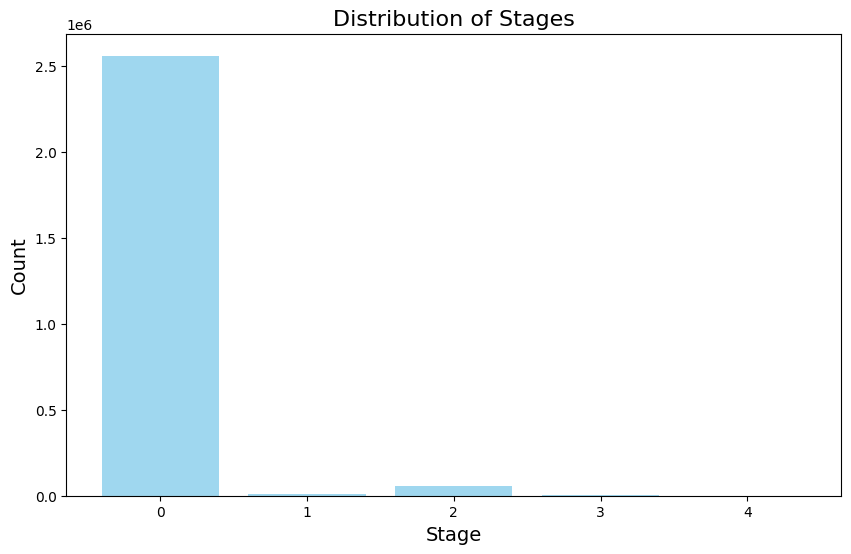

In [25]:
import matplotlib.pyplot as plt
# Đếm số lượng mẫu cho từng nhãn
stage_counts = df['Stage'].value_counts().sort_index()

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.bar(stage_counts.index, stage_counts.values, color='skyblue', alpha=0.8)

# Thêm nhãn, tiêu đề và lưới
plt.title('Distribution of Stages', fontsize=16)
plt.xlabel('Stage', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(ticks=stage_counts.index, labels=[
    'Benign',
    'Reconnaissance',
    'Establish Foothold',
    'Lateral Movement',
    'Data Exfiltration',
    'Cover up'
], rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

### Resample

In [26]:
from sklearn.utils import resample
import pandas as pd

# Định nghĩa số lượng mẫu mong muốn cho từng nhãn
desired_samples = {
    0: 1000,
    1: 3000,
    2: 3000,
    3: 1000,
    4: 359,
    # 5: 359
}

# Chia dữ liệu thành từng nhãn và resample theo số lượng mong muốn
df_balanced = pd.concat([
    resample(
        df[df['Stage'] == stage],
        replace=False,  # Không thay thế
        n_samples=desired_samples[stage],  # Số lượng mẫu mong muốn
        random_state=42
    )
    for stage in desired_samples.keys()
])

# Kiểm tra kết quả
print(df_balanced['Stage'].value_counts())

Stage
1    3000
2    3000
0    1000
3    1000
4     359
Name: count, dtype: int64


### Split the data into training and testing sets

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

X = df_balanced.drop('Stage', axis=1)
y = df_balanced['Stage']
x_train, x_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


In [28]:
# df.drop('Unnamed: 0', axis=1, inplace=True)
y.value_counts()

Stage
1    3000
2    3000
0    1000
3    1000
4     359
Name: count, dtype: int64

In [29]:
train_index = x_train.columns
train_index

Index(['Unnamed: 0', 'bidirectional_duration_ms', 'src2dst_duration_ms',
       'dst2src_duration_ms', 'src2dst_packets', 'dst2src_packets',
       'src2dst_bytes', 'dst2src_bytes', 'src2dst_max_ps', 'src2dst_min_ps',
       'src2dst_mean_ps', 'src2dst_stddev_ps', 'dst2src_max_ps',
       'dst2src_min_ps', 'dst2src_mean_ps', 'dst2src_stddev_ps',
       'bidirectional_mean_piat_ms', 'bidirectional_stddev_piat_ms',
       'bidirectional_max_piat_ms', 'bidirectional_min_piat_ms',
       'src2dst_mean_piat_ms', 'src2dst_stddev_piat_ms', 'src2dst_max_piat_ms',
       'src2dst_min_piat_ms', 'dst2src_mean_piat_ms', 'dst2src_stddev_piat_ms',
       'dst2src_max_piat_ms', 'dst2src_min_piat_ms',
       'bidirectional_fin_packets', 'src2dst_fin_packets',
       'dst2src_fin_packets', 'bidirectional_syn_packets',
       'src2dst_syn_packets', 'dst2src_syn_packets',
       'bidirectional_rst_packets', 'src2dst_rst_packets',
       'dst2src_rst_packets', 'bidirectional_psh_packets',
       'src2dst_

In [31]:
from sklearn.feature_selection import mutual_info_classif
mutual_info = mutual_info_classif(x_train, y_train)
mutual_info = pd.Series(mutual_info)
mutual_info.index = train_index
mutual_info.sort_values(ascending=False)

Unnamed: 0                      1.129017
dst2src_max_ps                  1.101153
dst2src_max_piat_ms             1.088877
bidirectional_max_piat_ms       1.085888
dst2src_stddev_ps               1.081458
src2dst_max_piat_ms             1.081270
dst2src_bytes                   1.076095
dst2src_mean_ps                 1.066572
src2dst_stddev_piat_ms          1.033217
src2dst_max_ps                  1.032835
bidirectional_stddev_piat_ms    1.032003
src2dst_bytes                   1.025617
bidirectional_mean_piat_ms      1.016444
src2dst_mean_piat_ms            1.015335
src2dst_stddev_ps               0.967800
src2dst_mean_ps                 0.950969
src2dst_ack_packets             0.941761
dst2src_stddev_piat_ms          0.927156
src2dst_packets                 0.917015
bidirectional_ack_packets       0.912464
dst2src_mean_piat_ms            0.903643
dst2src_duration_ms             0.886431
bidirectional_duration_ms       0.876914
src2dst_duration_ms             0.875763
dst2src_packets 

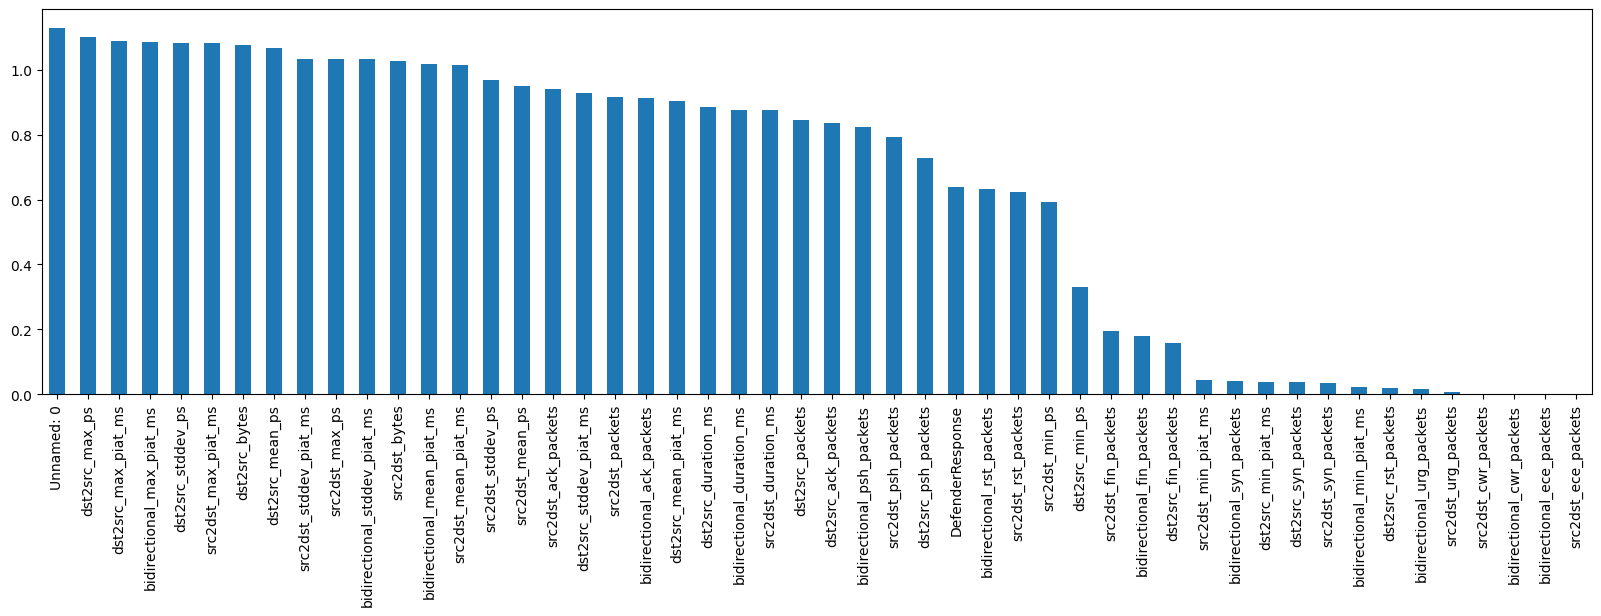

In [32]:
mutual_info.sort_values(ascending=False).plot.bar(figsize=(20, 5));


### Train the model

## XGBoost

In [ ]:
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
xgb_apt2021 = xgb.XGBClassifier(random_state = 42)

In [ ]:
xgb_apt2021.fit(x_train, y_train)

In [ ]:
y_pred = xgb_apt2021.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)


conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

print(classification_report(y_test, y_pred))

## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state=42, max_iter=2000)

In [ ]:
log_reg.fit(x_train, y_train)

In [ ]:
# Make predictions on the test set
y_pred = log_reg.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Print the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

## Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)

In [ ]:
dt.fit(x_train, y_train)

In [ ]:
# Make predictions on the test set
y_pred = dt.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Print the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=42)

In [ ]:
rf.fit(x_train, y_train)

In [ ]:
y_pred = rf.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)


conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

print(classification_report(y_test, y_pred))